## TOOBA AHMED ALVI - 31917


📂 Please upload your dataset CSV file


Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset (11).csv
✅ File uploaded: heart_failure_clinical_records_dataset (11).csv

🔹 Dataset Shape: (299, 13)
🔹 First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00          

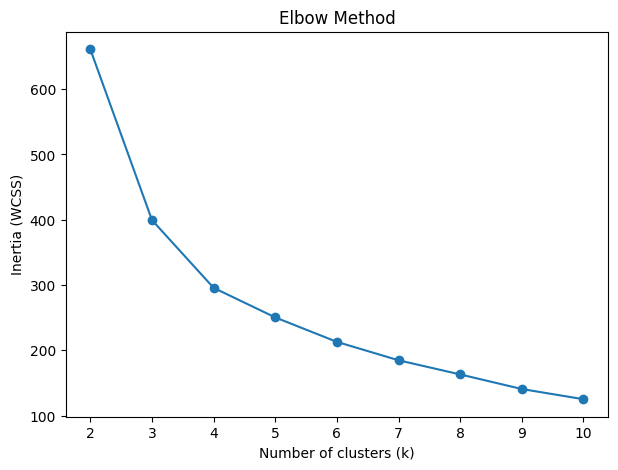

k=2 → Silhouette Score = 0.3976
k=3 → Silhouette Score = 0.4194
k=4 → Silhouette Score = 0.4171
k=5 → Silhouette Score = 0.3578
k=6 → Silhouette Score = 0.3633
k=7 → Silhouette Score = 0.3536
k=8 → Silhouette Score = 0.3478
k=9 → Silhouette Score = 0.3521
k=10 → Silhouette Score = 0.3681

⭐ Best k by silhouette: 3 (score=0.4194)


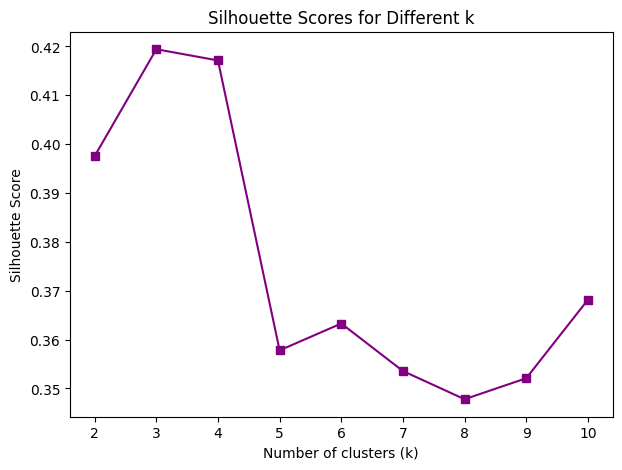


🔹 DBSCAN estimated clusters: 1
DBSCAN failed to form meaningful clusters (too many noise points).

📊 Cluster Counts:
Cluster
2    106
0     98
1     95
Name: count, dtype: int64


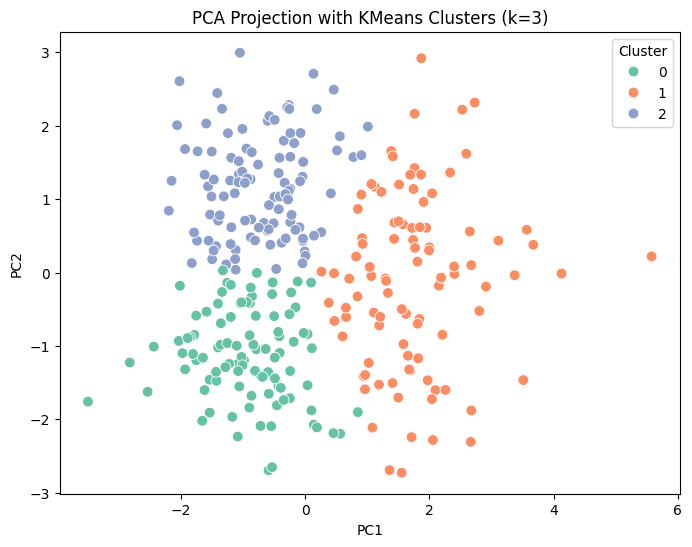

In [16]:
# ==============================
# Complete Clustering Script with PCA, Elbow, Silhouette, DBSCAN
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from google.colab import files

# -----------------------
# 1. Upload CSV file
# -----------------------
print("📂 Please upload your dataset CSV file")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ File uploaded: {filename}")

df = pd.read_csv(filename)
print("\n🔹 Dataset Shape:", df.shape)
print("🔹 First 5 rows:")
print(df.head())

# -----------------------
# 2. Preprocess Data
# -----------------------
DROP_COLUMNS = ["id", "timestamp"]  # adjust to your dataset
df = df.drop(columns=[c for c in DROP_COLUMNS if c in df.columns], errors="ignore")

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\n📝 Categorical columns:", categorical_cols)
print("📝 Numeric columns:", numeric_cols)

# One-hot encode categoricals
if categorical_cols:
    encoder = OneHotEncoder(drop="first", sparse_output=False)
    encoded = encoder.fit_transform(df[categorical_cols])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
    df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# -----------------------
# 3. PCA for Visualization
# -----------------------
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
print("\n🔹 PCA Explained Variance Ratio:", pca.explained_variance_ratio_)

# -----------------------
# 4. Elbow Method
# -----------------------
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.show()

# -----------------------
# 5. Silhouette Scores
# -----------------------
sil_scores = {}
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    sil_scores[k] = score
    print(f"k={k} → Silhouette Score = {score:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n⭐ Best k by silhouette: {best_k} (score={sil_scores[best_k]:.4f})")

plt.figure(figsize=(7,5))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="s", color="purple")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")
plt.show()

# -----------------------
# 6. DBSCAN
# -----------------------
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(pca_data)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"\n🔹 DBSCAN estimated clusters: {n_clusters_db}")

if n_clusters_db > 1:
    db_sil = silhouette_score(pca_data, db_labels)
    print(f"DBSCAN Silhouette Score = {db_sil:.4f}")
else:
    print("DBSCAN failed to form meaningful clusters (too many noise points).")

# -----------------------
# 7. Final Best Clustering with KMeans(best_k)
# -----------------------
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(pca_data)

df["Cluster"] = final_labels

print("\n📊 Cluster Counts:")
print(df["Cluster"].value_counts())

# -----------------------
# 8. Visualize Best Clusters on PCA
# -----------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=final_labels, palette="Set2", s=60)
plt.title(f"PCA Projection with KMeans Clusters (k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


**INTERPRETATION:**
For this dataset , KMeans with k=3 is the best choice (supported by both elbow and silhouette).

DBSCAN is not suitable for this dataset.

The PCA projection shows 3 reasonably separated groups (though some overlap is natural in clinical datasets).

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset (12).csv
✅ Data loaded, PCA applied, shape: (299, 2)
✅ Metrics calculated for k=2..10


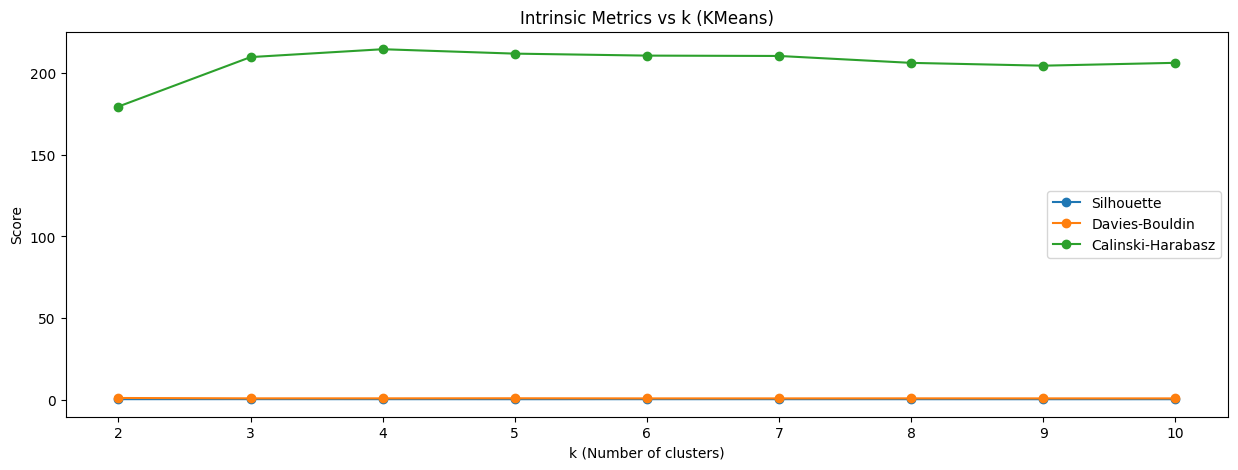

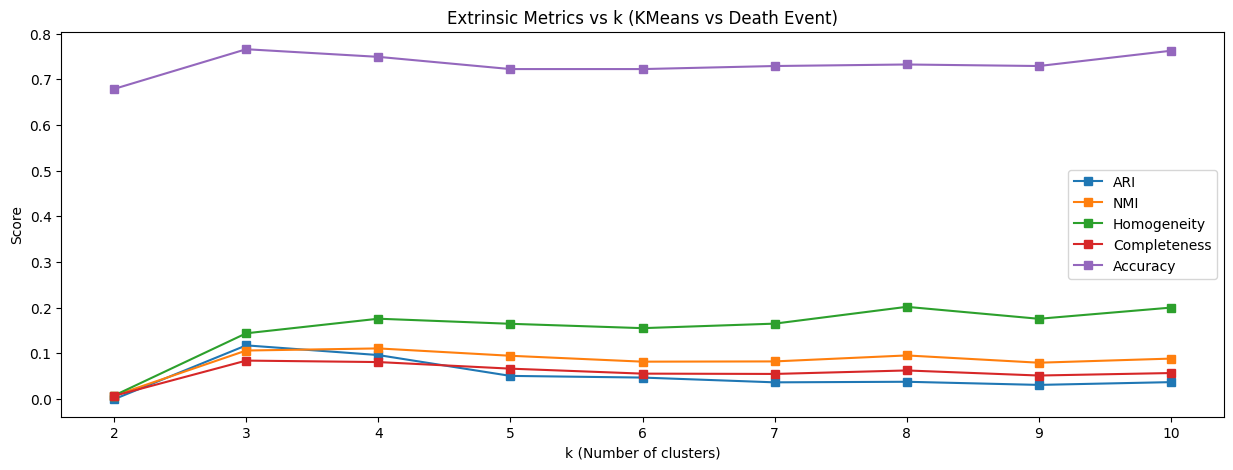

🏆 Best k (by Silhouette): 3


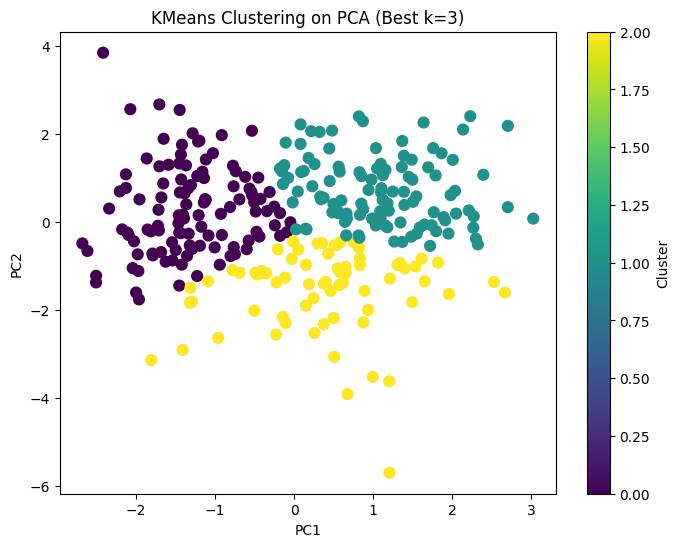

In [17]:
# ============================
# SUPERVISED K-MEANS CLUSTERING WITH METRICS PLOTS
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, accuracy_score
)
from sklearn.model_selection import train_test_split
from google.colab import files

# ============================
# Load dataset
# ============================

uploaded = files.upload()  # Upload your CSV
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# Target column
target_col = "death_event"
y = df[target_col].values

# Drop target for clustering
X = df.drop(columns=[target_col])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("✅ Data loaded, PCA applied, shape:", X_pca.shape)

# ============================
# K-Means clustering evaluation across k
# ============================

intrinsic_scores = {"Silhouette": [], "Davies-Bouldin": [], "Calinski-Harabasz": []}
extrinsic_scores = {"ARI": [], "NMI": [], "Homogeneity": [], "Completeness": [], "Accuracy": []}
k_values = range(2, 11)  # test k = 2 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    # Intrinsic
    intrinsic_scores["Silhouette"].append(silhouette_score(X_pca, labels))
    intrinsic_scores["Davies-Bouldin"].append(davies_bouldin_score(X_pca, labels))
    intrinsic_scores["Calinski-Harabasz"].append(calinski_harabasz_score(X_pca, labels))

    # Extrinsic (compare with ground truth death_event)
    extrinsic_scores["ARI"].append(adjusted_rand_score(y, labels))
    extrinsic_scores["NMI"].append(normalized_mutual_info_score(y, labels))
    extrinsic_scores["Homogeneity"].append(homogeneity_score(y, labels))
    extrinsic_scores["Completeness"].append(completeness_score(y, labels))

    # Accuracy → requires mapping clusters to labels
    from scipy.stats import mode
    mapped_labels = np.zeros_like(labels)
    for cluster in np.unique(labels):
        mask = labels == cluster
        mapped_labels[mask] = mode(y[mask], keepdims=True).mode[0]
    extrinsic_scores["Accuracy"].append(accuracy_score(y, mapped_labels))

print("✅ Metrics calculated for k=2..10")

# ============================
# Plot intrinsic metrics
# ============================

plt.figure(figsize=(15,5))
for metric, values in intrinsic_scores.items():
    plt.plot(k_values, values, marker="o", label=metric)
plt.xlabel("k (Number of clusters)")
plt.ylabel("Score")
plt.title("Intrinsic Metrics vs k (KMeans)")
plt.legend()
plt.show()

# ============================
# Plot extrinsic metrics
# ============================

plt.figure(figsize=(15,5))
for metric, values in extrinsic_scores.items():
    plt.plot(k_values, values, marker="s", label=metric)
plt.xlabel("k (Number of clusters)")
plt.ylabel("Score")
plt.title("Extrinsic Metrics vs k (KMeans vs Death Event)")
plt.legend()
plt.show()

# ============================
# Choose best k (based on Silhouette)
# ============================

best_k = k_values[np.argmax(intrinsic_scores["Silhouette"])]
print(f"🏆 Best k (by Silhouette): {best_k}")

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X_pca)

# ============================
# Visualize final clusters
# ============================

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=final_labels, cmap="viridis", s=60)
plt.title(f"KMeans Clustering on PCA (Best k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()


**INTERPRETATION:** The metrics comparison plot shows that clustering accuracy remains consistently higher than other metrics across all tested values for k (number of clusters). Homogeneity scores are noticeably better than ARI, NMI, and completeness, especially at k=3 which is also selected as the best value by silhouette analysis.